### functions/methods used in this demo:

**NumPy (`np`)**
Used for high-performance numerical operations and matrix algebra.
- `np.array()`: Creates an array or matrix.
- `np.zeros()`: Creates a matrix filled with zeros.
- `np.ones()`: Creates a matrix filled with ones.
- `np.eye()`: Creates an identity matrix.
- `np.random.rand()`: Generates random numbers between 0 and 1.
- `np.dot()` / `@`: Performs matrix multiplication.
- `.T`: Attribute to transpose a matrix.
- `np.percentile()`: Computes the $q^{th}$ percentile of data.
- `np.mean()`: Calculates the arithmetic mean.
- `np.arange()`: Returns evenly spaced values within a given interval.

**Pandas `pd`**

- `pd.read_parquet()`: Loads data from a Parquet file.
- `.groupby()`: Groups data by a specific column (e.g., 'year' or 'month').
- `.mean()`: Computes the mean of groups or columns.
- `.agg()`: Applies multiple statistical operations (like min and max) at once.
-`.size()`: Returns the number of elements in each group.
- `.unique()`: Finds unique values in a column.
- `.pivot()`: Reshapes data (similar to a pivot table) based on column values.
- `.cumcount()`: Generates a running count within each group.
- `.quantile()`: Calculates the specified quantile for a DataFrame or Series.
- `.gt()`: "Greater than" comparison (useful for broadcasting thresholds).
- `.iloc[]`: Integer-based indexing for selecting specific rows and columns.
- `.rolling()`: Provides rolling window calculations (e.g., moving averages).

**Matplotlib** (`plt`)
- `plt.figure()`: Initializes a new figure window.

- `plt.plot()`: Creates line plots.

- `plt.scatter()`: Creates scatter plots.

- `plt.xlabel()` / `plt.ylabel()`: Sets the labels for the x and y axes.

- `plt.title()`: Adds a title to the plot.

- `plt.legend()`: Adds a legend to identify different data series.

- `plt.grid()`: Overlays a grid on the plot.

- `plt.axis('equal')`: Sets equal scaling for x and y axes.

- `ax.twinx()`: Creates a secondary y-axis that shares the same x-axis.

- `plt.show()`: Displays the final plot.

In [119]:
import numpy as np
import pandas as pd
from scipy.io  import loadmat
import matplotlib.pyplot as plt

#### Matrix Algebra

In [120]:
# using numpy to create an array
x = np.array([[1, 2, 3], [4, 5, 6]])

# another option is to create matrices using the following functions:
zeros = np.zeros((2,3)) # matrix of zeros
ones = np.ones((2,3)) # matrix of ones
identity = np.eye(3) # identity. matrix
rand = np.random.rand(2,3) # random nums between 0 nd 1

identity

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [121]:
3*x

array([[ 3,  6,  9],
       [12, 15, 18]])

In [122]:
3 * x/2

array([[1.5, 3. , 4.5],
       [6. , 7.5, 9. ]])

##### Matrix addition and subtraction

In [123]:
x = np.array([[1,2],[3,4],[5,6]])
y = np.array([[6,5],[4,3],[2,1]])

print(x)
print(y)

[[1 2]
 [3 4]
 [5 6]]
[[6 5]
 [4 3]
 [2 1]]


In [124]:
x + y

array([[7, 7],
       [7, 7],
       [7, 7]])

In [125]:
x - y

array([[-5, -3],
       [-1,  1],
       [ 3,  5]])

##### Matrix Multiplication

- `@` symbol is for matrix multiplication (or `np.dot`)
- `*` symbol is for element wise multiplication
- `.T` is the transpose of a matrix

In [126]:
# (3x2) @ (2x3) = (3x3)
x @ y.T

array([[16, 10,  4],
       [38, 24, 10],
       [60, 38, 16]])

In [127]:
# (2x3) @ (3x2) = (2x2)
x.T @ y

array([[28, 19],
       [40, 28]])

Also works for lists

In [128]:
df = pd.read_parquet('data/df_SIO_TEMP.parquet')
temps = df['T'].values[:150]

#### computing percentiles

In [129]:
# 99th percentile
p99 = np.percentile(temps, 99)
p01 = np.percentile(temps, 1)

print("The 99th percentile is:", p99, 'C')
print("The 1st percentile is:", p01, 'C')

The 99th percentile is: 17.3 C
The 1st percentile is: 11.398 C


#### Pandas GroupBy

In [130]:
# Let's find the average temperature (T) for every year in our dataset
yearly_avg = df.groupby('year')['T'].mean()

print("Average Summer Temp by Year:")
print(yearly_avg)

Average Summer Temp by Year:
year
1917    16.713973
1918    17.380274
1919    16.901507
1920    16.554508
1921    16.572329
          ...    
2021    17.852877
2022    18.289863
2023    17.596301
2024    17.871038
2025    17.971875
Name: T, Length: 109, dtype: float64


In [131]:
# Multiple Statistics at once
# Let's find the Hottest and Coldest day of every year
summer_stats = df.groupby('year')['T'].agg(['min', 'max'])

print("Annual Temperature Extremes:")
print(summer_stats)

Annual Temperature Extremes:
       min   max
year            
1917  11.3  23.1
1918  12.5  22.9
1919  11.7  22.8
1920  12.0  22.6
1921  12.5  23.3
...    ...   ...
2021  13.1  24.9
2022  13.5  24.8
2023  12.4  23.6
2024  12.9  24.6
2025  12.5  24.1

[109 rows x 2 columns]


In [132]:
# If you want to see how many days are recorded for each month across all years:
month_counts = df.groupby('month').size()

print("Number of days recorded per month:")
print(month_counts)

Number of days recorded per month:
month
1     3379
2     3079
3     3379
4     3270
5     3379
6     3270
7     3379
8     3379
9     3270
10    3379
11    3240
12    3348
dtype: int64


#### Form a 2-dimensional array of T summer day vs year using a for loop   


In [133]:
yrs = df['year'].unique() # .unique() gets unique values
nyr = len(yrs)
nday = 31 + 31 + 30 # July (31) + Aug (31) + Sep (30)

# create a matrix to hold the data 
Tsummer = np.zeros((nday, nyr))

for j, year in enumerate(yrs):
    # Filter for months 7, 8, and 9 for the specific year
    summer_data = df[(df.index.month >= 7) & 
                     (df.index.month <= 9) & 
                     (df.index.year == year)]['T']
    
    # Fill the column (ensure the lengths match)
    Tsummer[:, j] = summer_data.values[:nday]


#### Same process using pivot tables (perks of Pandas)

In [134]:
# filter for summer
summer_df = df[(df['month'] >= 7) & (df['month'] <= 9)]

# assign the year and the day-count-within-summer
# cumcount() gives a running count within each group 

summer_df['yr'] = summer_df['year']
summer_df['day_idx'] = summer_df.groupby('yr').cumcount()

# pivot: Rows = day_idx, Columns = yr, Values = T
Tsummer_df = summer_df.pivot(index='day_idx', columns='yr', values='T')
Tsummer=Tsummer_df.to_numpy() # makes into an array
Tsummer

/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_55300/2473293254.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summer_df['yr'] = summer_df['year']
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_55300/2473293254.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summer_df['day_idx'] = summer_df.groupby('yr').cumcount()


array([[21.1 , 20.1 , 20.2 , ..., 21.1 , 19.6 , 17.1 ],
       [21.3 , 19.8 , 20.8 , ..., 20.5 , 21.7 , 18.2 ],
       [22.1 , 20.2 , 20.8 , ..., 18.3 , 21.7 , 18.1 ],
       ...,
       [19.5 , 18.9 , 19.2 , ..., 19.  , 16.7 , 18.7 ],
       [18.7 , 19.2 , 19.6 , ..., 19.9 , 16.85, 20.1 ],
       [18.9 , 19.5 , 19.  , ..., 20.9 , 17.  , 19.7 ]])

#### plot all years vs day of summer starting with July 1

Pandas and Matplotlib work seamlessly together. plotting a dataframe directly treats columns as individual lines

In [135]:
Tsummer_df

yr,1917,1918,1919,1920,1921,1922,1923,1924,1925,1926,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
day_idx,,,,,,,,,,,,,,,,,,,,,
0,21.1,20.1,20.2,20.5,20.10,21.00,19.30,20.10,21.1,19.8,...,21.2,19.6,21.0,17.0,20.3,20.1,20.7,21.1,19.60,17.1
1,21.3,19.8,20.8,20.6,20.20,21.15,19.70,20.30,21.3,21.0,...,21.7,20.8,21.6,18.2,20.1,20.2,20.0,20.5,21.70,18.2
2,22.1,20.2,20.8,19.5,20.05,21.30,20.00,19.50,21.1,20.6,...,22.1,20.5,22.3,17.3,19.6,20.8,20.1,18.3,21.70,18.1
3,21.1,20.5,21.0,18.3,19.90,21.70,19.85,20.05,21.2,22.9,...,21.9,20.2,22.0,19.1,19.7,21.3,21.1,17.2,22.20,20.1
4,20.1,20.8,20.8,17.9,20.40,21.10,19.70,20.60,21.9,22.0,...,22.5,20.7,22.5,19.1,21.8,21.7,21.7,16.9,21.80,20.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,18.9,19.5,19.1,18.6,17.80,18.70,19.90,17.90,17.8,17.2,...,18.7,20.4,21.1,21.1,20.7,18.4,22.1,18.3,17.30,18.8
88,18.7,18.9,18.8,18.6,18.90,18.50,19.30,18.60,19.5,17.8,...,18.9,21.9,20.8,21.2,21.9,18.1,22.5,18.5,17.20,20.4
89,19.5,18.9,19.2,19.1,19.70,18.70,19.50,18.80,18.1,17.9,...,19.9,20.8,20.8,21.7,21.0,17.5,22.8,19.0,16.70,18.7


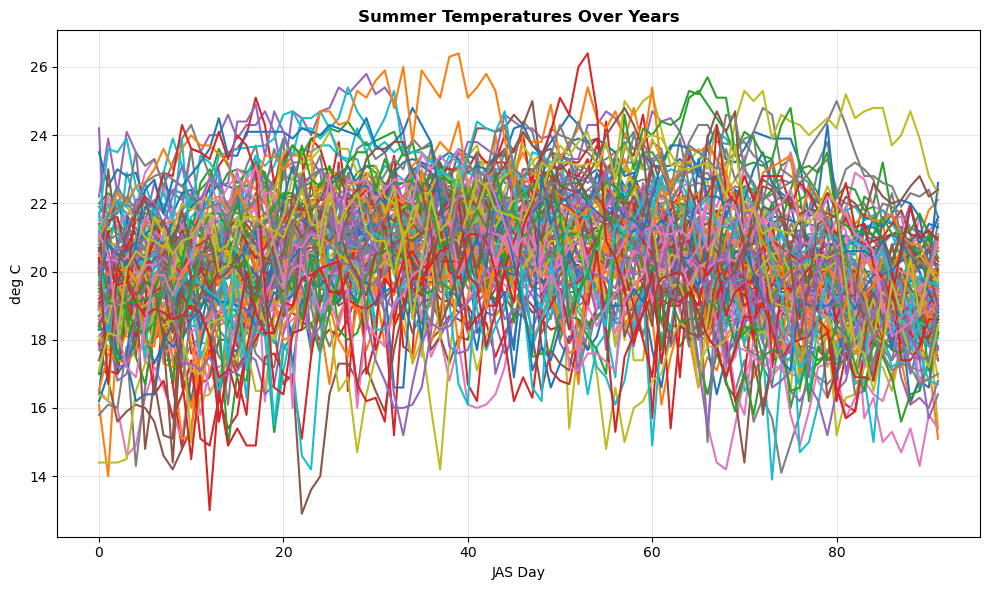

In [136]:
# plotting a dataframe

plt.figure(figsize=(10,6))

plt.plot(Tsummer_df)
# labels and title 
plt.xlabel('JAS Day')
plt.ylabel('deg C')
plt.title('Summer Temperatures Over Years', fontweight='bold')

#plt.legend(Tsummer_df.columns, title='Year', loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### plot summer temps in deg F for all years vs days of summer

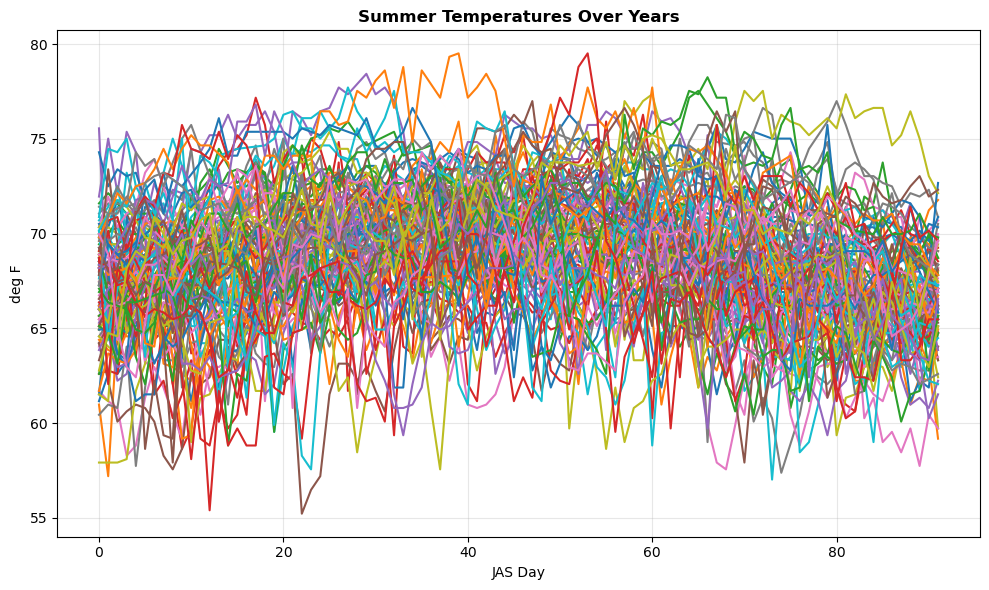

In [137]:
plt.figure(figsize=(10,6))

plt.plot(Tsummer_df*9/5 + 32)
# labels and title 
plt.xlabel('JAS Day')
plt.ylabel('deg F')
plt.title('Summer Temperatures Over Years', fontweight='bold')

#plt.legend(Tsummer_df.columns, title='Year', loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### plot the mean (over all years) for each summer day 

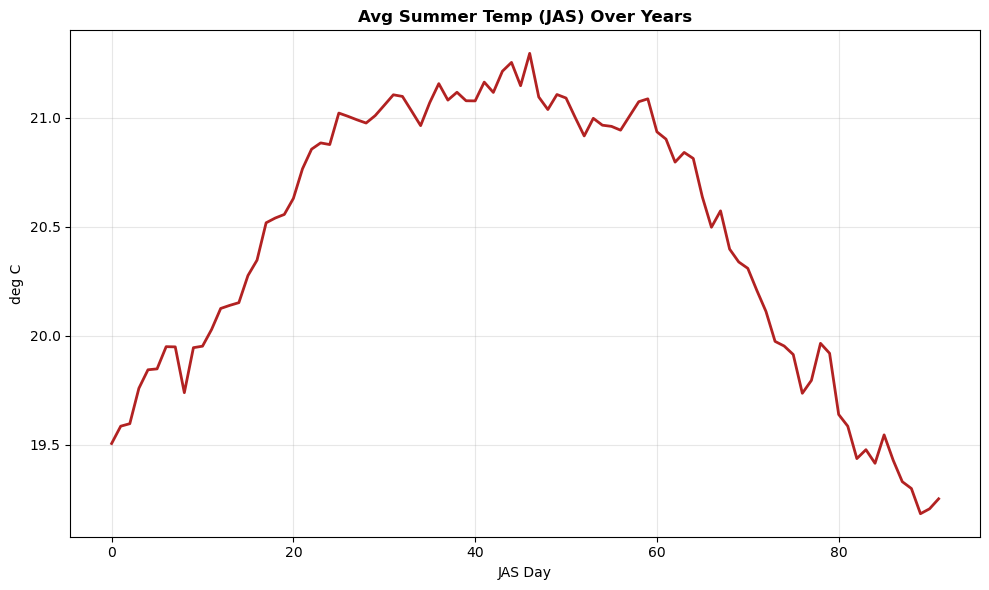

In [138]:
plt.figure(figsize=(10,6))

plt.plot(Tsummer_df.mean(axis=1), color='firebrick', linewidth=2)

plt.xlabel('JAS Day')
plt.ylabel('deg C')
plt.title('Avg Summer Temp (JAS) Over Years', fontweight='bold')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### plot the mean (over all summer days) for each year

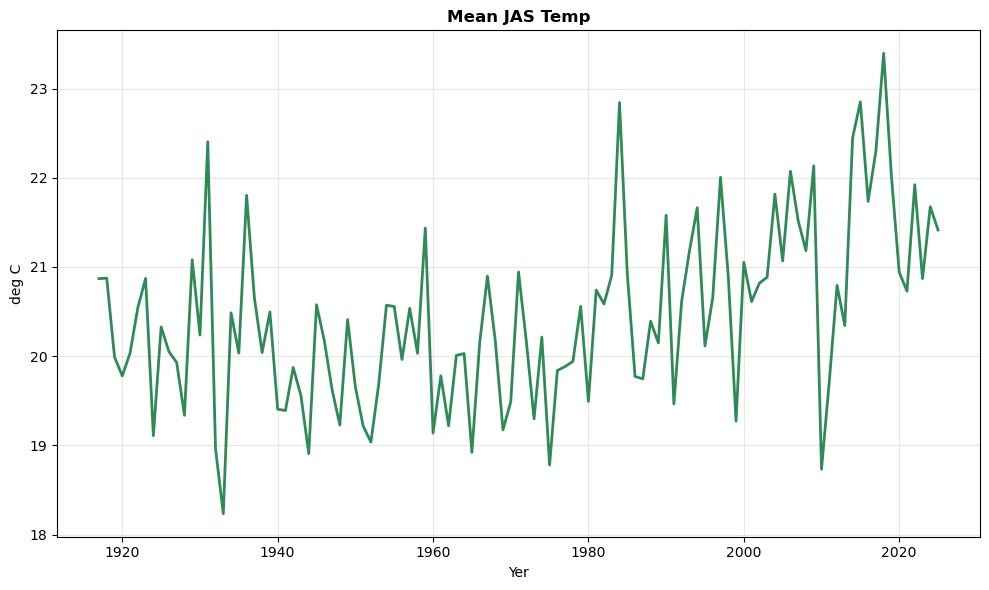

In [139]:
plt.figure(figsize=(10,6))

plt.plot(Tsummer_df.mean(axis=0), color='seagreen', linewidth=2)

plt.xlabel('Yer')
plt.ylabel('deg C')
plt.title('Mean JAS Temp', fontweight='bold')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Plot the 10th and 90th percentile (over all years) for each summer day 

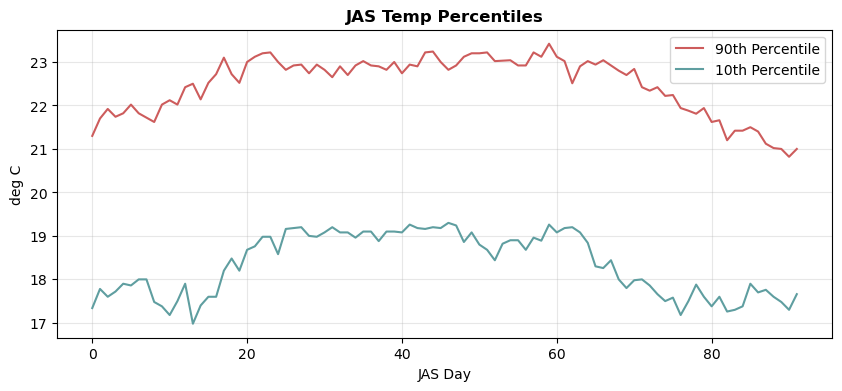

In [140]:
# compute percentiles
p90 = np.percentile(Tsummer, 90, axis=1)
p10 = np.percentile(Tsummer, 10, axis=1)

plt.figure(figsize=(10,4))

plt.plot(p90, label='90th Percentile', color='IndianRed')
plt.plot(p10, label='10th Percentile', color='cadetblue')

plt.xlabel('JAS Day')
plt.ylabel('deg C')
plt.title('JAS Temp Percentiles', fontweight='bold')

plt.legend(loc='best')
plt.grid(True, alpha=0.3)

#### Compute number of days above 95th percentile temperature

In [141]:
Tsummer_df

yr,1917,1918,1919,1920,1921,1922,1923,1924,1925,1926,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
day_idx,,,,,,,,,,,,,,,,,,,,,
0,21.1,20.1,20.2,20.5,20.10,21.00,19.30,20.10,21.1,19.8,...,21.2,19.6,21.0,17.0,20.3,20.1,20.7,21.1,19.60,17.1
1,21.3,19.8,20.8,20.6,20.20,21.15,19.70,20.30,21.3,21.0,...,21.7,20.8,21.6,18.2,20.1,20.2,20.0,20.5,21.70,18.2
2,22.1,20.2,20.8,19.5,20.05,21.30,20.00,19.50,21.1,20.6,...,22.1,20.5,22.3,17.3,19.6,20.8,20.1,18.3,21.70,18.1
3,21.1,20.5,21.0,18.3,19.90,21.70,19.85,20.05,21.2,22.9,...,21.9,20.2,22.0,19.1,19.7,21.3,21.1,17.2,22.20,20.1
4,20.1,20.8,20.8,17.9,20.40,21.10,19.70,20.60,21.9,22.0,...,22.5,20.7,22.5,19.1,21.8,21.7,21.7,16.9,21.80,20.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,18.9,19.5,19.1,18.6,17.80,18.70,19.90,17.90,17.8,17.2,...,18.7,20.4,21.1,21.1,20.7,18.4,22.1,18.3,17.30,18.8
88,18.7,18.9,18.8,18.6,18.90,18.50,19.30,18.60,19.5,17.8,...,18.9,21.9,20.8,21.2,21.9,18.1,22.5,18.5,17.20,20.4
89,19.5,18.9,19.2,19.1,19.70,18.70,19.50,18.80,18.1,17.9,...,19.9,20.8,20.8,21.7,21.0,17.5,22.8,19.0,16.70,18.7


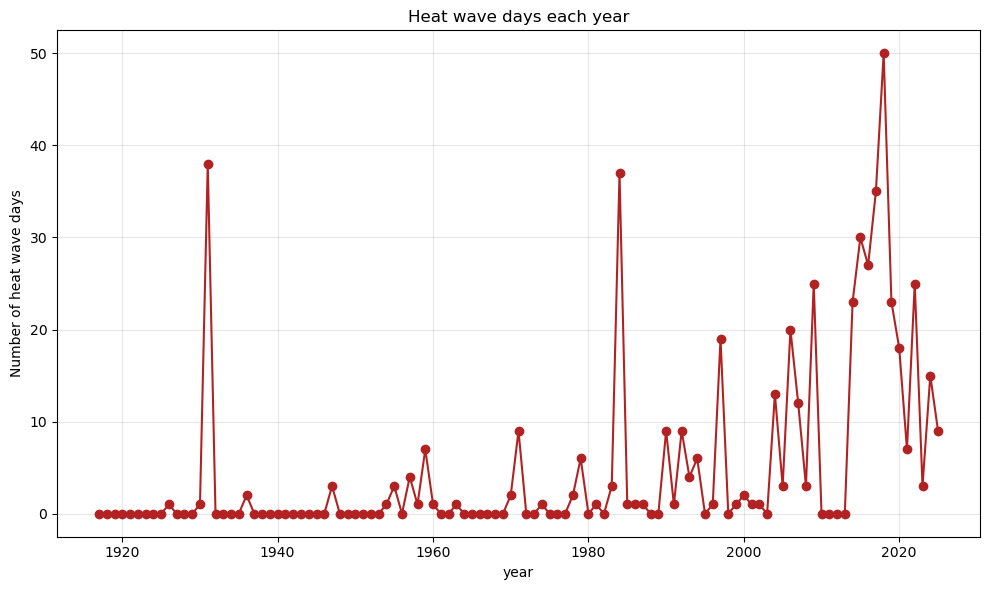

In [142]:
# 95th percentile across all years for each day 
lim95 = Tsummer_df.quantile(0.95, axis=1)

# compare each year's column to that threshold
# .gt (greater than) compares the dataframe to 95th percentile
heat_days = Tsummer_df.gt(lim95, axis=0).sum()

# plotting
plt.figure(figsize=(10,6))
heat_days.plot(marker='o', color='firebrick') # pandas uses column names as x axis automatically 

plt.xlabel('year')
plt.ylabel('Number of heat wave days')
plt.title('Heat wave days each year')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### compute number of heat wave days vs JAS day

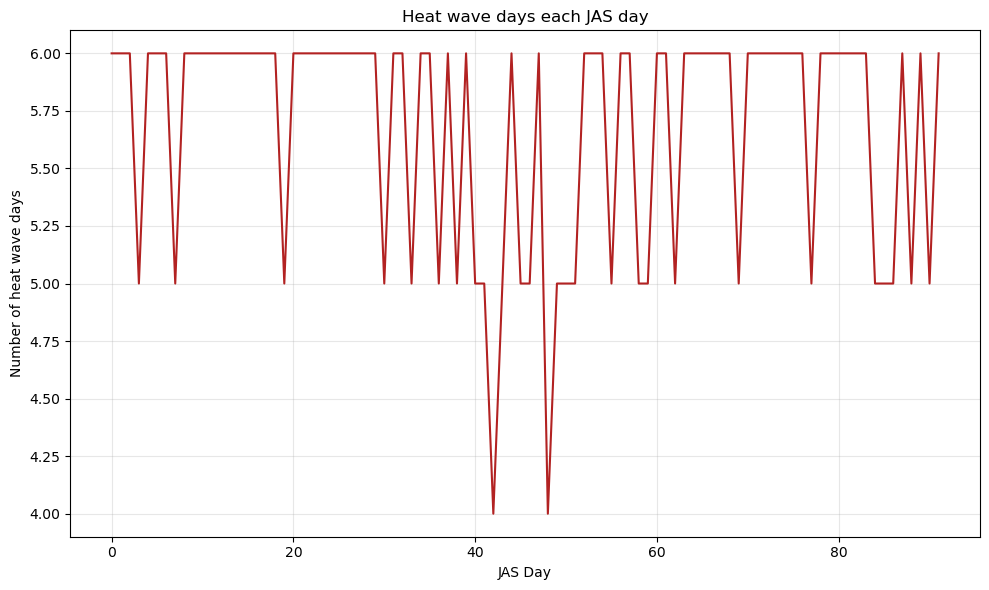

In [143]:
# we can use lim_95 from before
# compare each year's column to that threshold
# .gt (greater than) compares the dataframe to 95th percentile
# .sum(axis=1) counts how many years were "True" for each specific day
heat_JASday = Tsummer_df.gt(lim95, axis=0).sum(axis=1)

# plotting
plt.figure(figsize=(10,6))
plt.plot(heat_JASday, color='firebrick') # pandas uses column names as x axis automatically 

plt.xlabel('JAS Day')
plt.ylabel('Number of heat wave days')
plt.title('Heat wave days each JAS day')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### number of heart wave days vs JAS days over first 30 years and last 30 years

/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_55300/1479396536.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


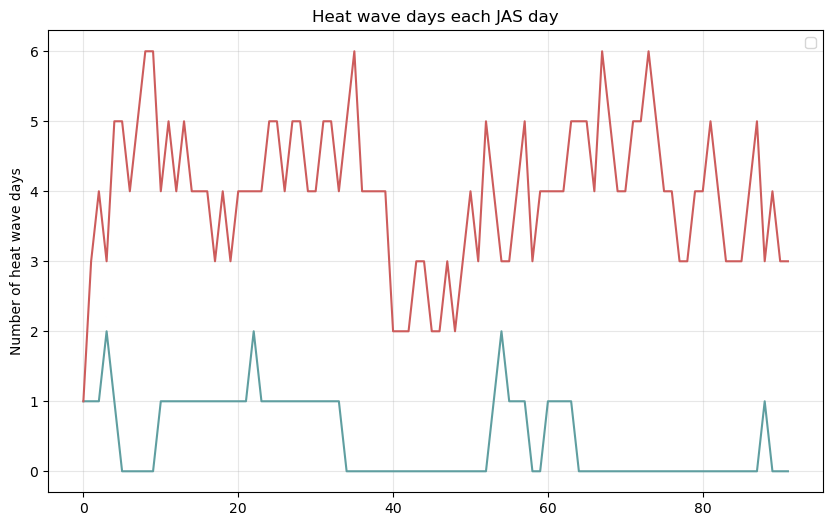

In [144]:
# use lim 90 for 95th percentile threshold

# compare hole df to the threshold
is_heat_day = Tsummer_df.gt(lim95, axis=0)

# [rows, columns]
# here the datafframe is in [days, yrs]
# want to find first and last 30 years
#.sum sums the "True" values
first30= is_heat_day.iloc[:, :30].sum(axis=1)
last30 = is_heat_day.iloc[:, -30:].sum(axis=1)

# plotting
plt.figure(figsize=(10,6))

plt.plot(first30, color='cadetblue')
plt.plot(last30, color='IndianRed')

plt.ylabel('Number of heat wave days')
plt.title('Heat wave days each JAS day')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### plot JAS mean temp and Number of heat wave days on the same plot

they have the same x axis but different y axis. We use `.twinx()` to create another y axis

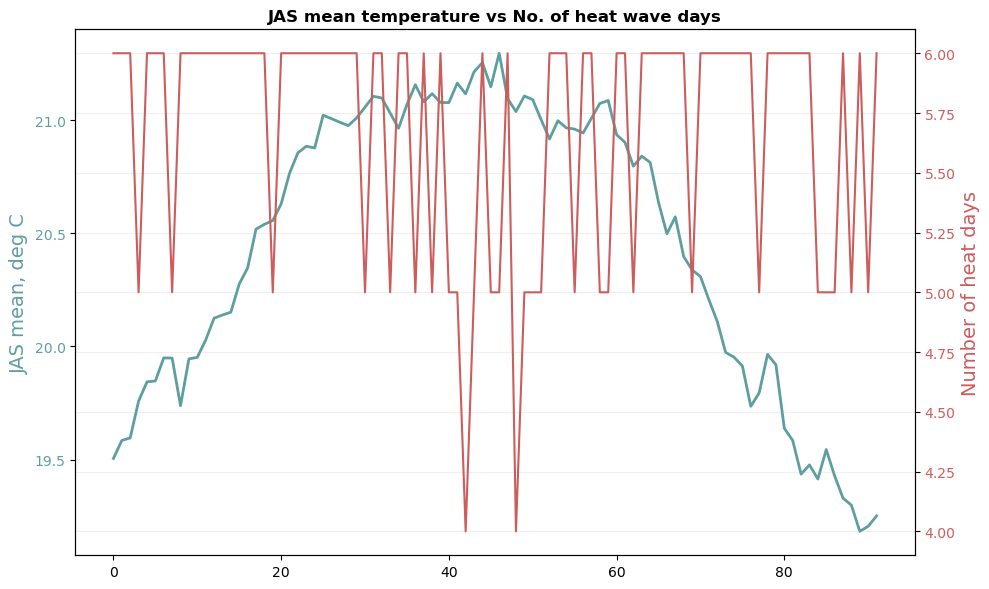

In [145]:
# Mean temperature for each summer day across all years
y1 = Tsummer_df.mean(axis=1)
# Total number of heat days for each summer day (as we did before)
lim95 = Tsummer_df.quantile(0.95, axis=1)
y2 = Tsummer_df.gt(lim95, axis=0).sum(axis=1)

# plotting: note the syntax fig, ax1

fig, ax1 = plt.subplots(figsize=(10, 6))

# mean temp
c1 = 'cadetblue'
ax1.plot(y1, color=c1, linewidth=2, label='Mean Temp')
ax1.set_ylabel('JAS mean, deg C', color=c1, fontsize=14)
ax1.tick_params(axis='y', labelcolor=c1)


# number of heat days 
c2 = 'IndianRed'
ax2 = ax1.twinx()  # create another y axis 
ax2.set_ylabel('Number of heat days', color=c2, fontsize=14)
ax2.plot(y2, color=c2, label='Heat Days')
ax2.tick_params(axis='y', labelcolor=c2)

plt.title('JAS mean temperature vs No. of heat wave days', fontweight='bold')
plt.tight_layout() # Ensures labels don't get cut off
plt.grid(True, alpha=0.2)
plt.show()

#### compute annual avg temp vs JAS avg temp using scatter plots


In [147]:
t_annual

year
1917    16.713973
1918    17.380274
1919    16.901507
1920    16.554508
1921    16.572329
          ...    
2021    17.852877
2022    18.289863
2023    17.596301
2024    17.871038
2025    17.971875
Name: T, Length: 109, dtype: float64

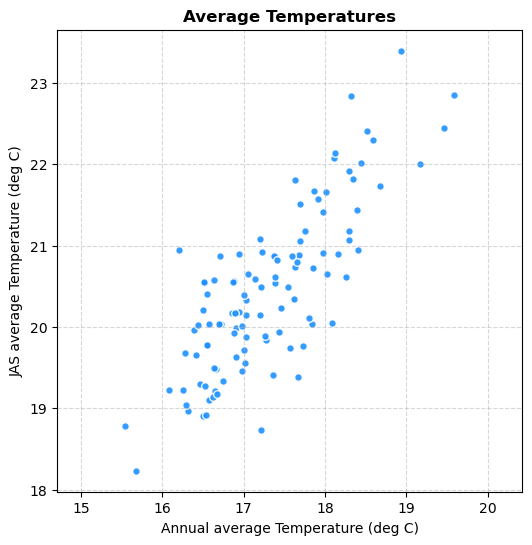

In [148]:
# Annual Mean 
t_annual = df.groupby('year')['T'].mean()

# summer mean
t_summer_mean = Tsummer_df.mean(axis=0)

# plot
plt.figure(figsize=(6, 6)) # Square-ish figure to complement 'equal' axis

plt.scatter(t_annual, t_summer_mean, s=30, c='dodgerblue', edgecolors='white', alpha=0.9)

plt.xlabel('Annual average Temperature (deg C)')
plt.ylabel('JAS average Temperature (deg C)')
plt.title('Average Temperatures', fontweight='bold')

plt.axis('equal')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()